
# **Proyecto 2**
## **Database Setup y Queries**
### **Minería de Grafos**  

     Docente: Victor Hugo Ortega
     Aissa Berenice González Fosado
     Maximiliano Aguayo
     Ivan Morales

<img src="https://iteso.mx/documents/27014/202031/Logo-ITESO-MinimoH.png"
     width="400"/>

---

# Proyecto 2 — Metro CDMX en Neo4j

Este notebook:

1. Se conecta a Neo4j usando las variables del archivo `.env`.
2. Crea (o reemplaza) la base de datos **`proyecto-2`**.
3. Carga los nodos (`estacion`) desde `data/processed/metro_nodes_con_afluencia.csv`.
4. Carga las relaciones (`CONECTA_CON`) desde `data/processed/metro_edges.csv` haciendo el `MATCH` por **NOMBRE + LINEA** (para que las estaciones de transbordo no se confundan).
5. Corre los queries del archivo `proyecto2.cql`: subgrafos GDS, top de afluencia, Betweenness, Louvain, PageRank y Closeness.

> El nombre `proyecto-2` lleva guion, así que en Cypher siempre va entre **backticks**: `` `proyecto-2` ``.


### **Setup de la conexión, la base de datos y sus contenidos**

**Imports y configuración**

In [4]:
#!pip install neo4j graphdatascience python-dotenv pandas

In [37]:
import os
import pandas as pd
from dotenv import load_dotenv
from neo4j import GraphDatabase
from graphdatascience import GraphDataScience

load_dotenv(override=True)

config = {
    "uri":      os.environ["NEO4J_URI"],
    "user":     os.environ["NEO4J_USER"],
    "password": os.environ["NEO4J_PASSWORD"],
    "db":       os.environ["NEO4J_DB"],
}

print(f"URI : {config['uri']}")
print(f"User: {config['user']}")
print(f"DB  : {config['db']}")

URI : neo4j://127.0.0.1:7687
User: neo4j
DB  : proyecto-2


**Conexión al servidor Neo4j**

In [38]:
driver = GraphDatabase.driver(config["uri"], auth=(config["user"], config["password"]))

try:
    with driver.session() as sesion:
        result = sesion.run("RETURN 1 AS ok")
        if result.single()["ok"] == 1:
            print("Conexión exitosa a Neo4j")
except Exception as e:
    print(f"Falló la conexión: {e}")

Conexión exitosa a Neo4j


**Crear la base de datos `proyecto-2`**

In [39]:
db_name = config["db"]  # "proyecto-2"

with driver.session(database="system") as sesion:
    # OR REPLACE deja la base recién creada y vacía
    sesion.run(f"CREATE OR REPLACE DATABASE `{db_name}` WAIT")
    # Mostramos el estado
    info = sesion.run(
        "SHOW DATABASES YIELD name, currentStatus WHERE name = $n RETURN name, currentStatus",
        n=db_name,
    ).single()
    print(f"Base de datos '{info['name']}' está en estado: {info['currentStatus']}")

Base de datos 'proyecto-2' está en estado: online


**Conexión con Graph Data Science y al `proyecto-2`**

In [40]:
gds = GraphDataScience(config["uri"], auth=(config["user"], config["password"]))
gds.set_database(db_name)

test = gds.run_cypher("RETURN 1 AS prueba")
print("Conectado a GDS, versión:", gds.version())
test

Conectado a GDS, versión: 2026.4.0


,prueba
0,1


**Lectura de los CSV con pandas**

Leemos los archivos desde Python para despues pasarlos con un query de Cypher

In [41]:
NODES_PATH = "data/processed/metro_nodes_con_afluencia.csv"
EDGES_PATH = "data/processed/metro_edges.csv"

nodes_df = pd.read_csv(NODES_PATH)
edges_df = pd.read_csv(EDGES_PATH)

# 'AÑO' lleva ñ -> lo renombramos a 'ANIO' para evitar tener que poner backticks en Cypher
nodes_df = nodes_df.rename(columns={"AÑO": "ANIO"})

# Forzamos LINEA a string (hay líneas como 'A' y 'B' además de números)
nodes_df["LINEA"] = nodes_df["LINEA"].astype(str)
edges_df["linea"] = edges_df["linea"].astype(str)

print(f"Nodos : {len(nodes_df)} filas")
print(f"Edges : {len(edges_df)} filas")
nodes_df.head(3)

Nodos : 163 filas
Edges : 183 filas


,NOMBRE,LINEA,SISTEMA,TIPO,ALCALDIAS,ANIO,CVE_EST,lon,lat,afluencia
0,Pantitlán,1,STC Metro,Terminal / Transbordo,Venustiano Carranza,1984,STC0101,-99.074736,19.416334,38025.48497
1,Zaragoza,1,STC Metro,Intermedia,Venustiano Carranza,1969,STC0102,-99.082289,19.411920,23064.42623
2,Gomez Farías,1,STC Metro,Intermedia,Venustiano Carranza,1969,STC0103,-99.090210,19.416478,19903.29235


In [42]:
edges_df.head(3)

,origen,destino,linea,sistema,tipo_origen,tipo_destino,alcaldia_origen,alcaldia_destino,origen_lon,origen_lat,destino_lon,destino_lat,distancia_track_m,distancia_track_km,distancia_recta_m,distancia_recta_km
0,Pantitlán,Zaragoza,1,STC Metro,Terminal / Transbordo,Intermedia,Venustiano Carranza,Venustiano Carranza,-99.074736,19.416334,-99.082289,19.411920,1428.684879,1.428685,931.302727,0.931303
1,Zaragoza,Gomez Farías,1,STC Metro,Intermedia,Intermedia,Venustiano Carranza,Venustiano Carranza,-99.082289,19.411920,-99.090210,19.416478,972.646262,0.972646,972.643887,0.972644
2,Gomez Farías,Boulevard Puerto Aéreo,1,STC Metro,Intermedia,Intermedia,Venustiano Carranza,Venustiano Carranza,-99.090210,19.416478,-99.096259,19.419942,741.681225,0.741681,741.673190,0.741673


**Cargar nodos `:estacion`**

Usamos `UNWIND $rows` para mandar todas las filas en una sola transacción.


In [43]:
nodes_records = nodes_df.to_dict(orient="records")

nodes_query = """
UNWIND $rows AS row
MERGE (e:estacion {CVE_EST: row.CVE_EST})
SET e.NOMBRE    = row.NOMBRE,
    e.LINEA     = row.LINEA,
    e.SISTEMA   = row.SISTEMA,
    e.TIPO      = row.TIPO,
    e.ALCALDIAS = row.ALCALDIAS,
    e.ANIO      = toInteger(row.ANIO),
    e.lon       = toFloat(row.lon),
    e.lat       = toFloat(row.lat),
    e.afluencia = toFloat(row.afluencia)
RETURN count(e) AS creados
"""

res = gds.run_cypher(nodes_query, params={"rows": nodes_records})
res

,creados
0,163


**Cargar relaciones `CONECTA_CON`**

Hacemos el `MATCH` solo por **`NOMBRE`** para incluir las aristas de transbordo entre líneas (Pantitlán L1 ↔ Pantitlán L9, Hidalgo L2 ↔ Hidalgo L3, etc.). Así el grafo queda conectado y nuestros algoritmos van a tener sentido.

In [44]:
edges_records = edges_df.to_dict(orient="records")

edges_query = """
UNWIND $rows AS row

MATCH (o:estacion {NOMBRE: row.origen})
MATCH (d:estacion {NOMBRE: row.destino})
WHERE o <> d
MERGE (o)-[r:CONECTA_CON {linea: row.linea}]->(d)
SET r.sistema           = row.sistema,
    r.distancia_track_m = toFloat(row.distancia_track_m),
    r.distancia_track_km= toFloat(row.distancia_track_km),
    r.distancia_recta_m = toFloat(row.distancia_recta_m),
    r.distancia_recta_km= toFloat(row.distancia_recta_km)
RETURN count(r) AS creadas
"""

res = gds.run_cypher(edges_query, params={"rows": edges_records})
res

,creadas
0,183


**Verificación de la carga**

In [45]:
gds.run_cypher("""
    MATCH (e:estacion)
    OPTIONAL MATCH ()-[r:CONECTA_CON]->()
    RETURN count(DISTINCT e) AS num_estaciones,
           count(DISTINCT r) AS num_conexiones
""")

,num_estaciones,num_conexiones
0,163,183


In [46]:
# Un vistazo a una estación cualquiera con sus vecinos
gds.run_cypher("""
    MATCH (e:estacion {NOMBRE: 'Pantitlán'})-[r:CONECTA_CON]->(v:estacion)
    RETURN e.NOMBRE AS origen, e.LINEA AS linea_origen,
           v.NOMBRE AS destino, v.LINEA AS linea_destino,
           r.distancia_track_m AS dist_m
    ORDER BY linea_origen, destino
""")

,origen,linea_origen,destino,linea_destino,dist_m
0,Pantitlán,1,Agrícola Oriental,A,1552.511505
1,Pantitlán,1,Puebla,9,1538.076890
2,Pantitlán,1,Zaragoza,1,1428.684879


---
### **Queries para el reporte del proyecto**

**Estructura de la Red**

Conteo por línea y por sistema

In [50]:
gds.run_cypher("""
    MATCH (n:estacion)
    RETURN n.LINEA AS Linea,
        n.SISTEMA AS Sistema,
        count(*) AS NumEstaciones,
        sum(n.afluencia) AS AfluenciaTotal,
        avg(n.afluencia) AS AfluenciaPromedio
    ORDER BY AfluenciaTotal DESC
""")

,Linea,Sistema,NumEstaciones,AfluenciaTotal,AfluenciaPromedio
0,2,STC Metro,23,529150.294626,23006.534549
1,3,STC Metro,19,426858.210373,22466.221599
2,1,STC Metro,20,349205.651190,17460.282560
3,B,STC Metro,16,303921.584694,18995.099043
4,8,STC Metro,15,280797.620220,18719.841348
5,12,STC Metro,16,277391.726767,17336.982923
6,7,STC Metro,11,201503.765027,18318.524093
7,A,STC Metro,9,180449.270490,20049.918943
8,9,STC Metro,7,122749.218580,17535.602654
9,5,STC Metro,10,95848.131151,9584.813115


Estaciones por alcaldía

In [52]:
gds.run_cypher("""
    MATCH (n:estacion)
    RETURN n.ALCALDIAS AS Alcaldia,
        count(*) AS NumEstaciones,
        sum(n.afluencia) AS AfluenciaTotal
    ORDER BY NumEstaciones DESC
""")

,Alcaldia,NumEstaciones,AfluenciaTotal
0,Cuauhtémoc,30,554711.226322
1,Venustiano Carranza,20,287280.270484
2,Iztapalapa,19,377883.166663
3,Benito Juárez,17,259648.575131
4,Gustavo A. Madero,16,266493.475401
5,Miguel Hidalgo,12,214883.212666
6,Azcapotzalco,9,95069.603824
7,Coyoacán,5,182533.959020
8,Iztacalco,5,63095.508196
9,Tláhuac,5,105544.554643


Distribución por tipo (Terminal, Intermedia, Transbordo)


In [53]:
gds.run_cypher("""
    MATCH (n:estacion)
    RETURN n.TIPO AS Tipo, count(*) AS Cuantas
    ORDER BY Cuantas DESC    
""")

,Tipo,Cuantas
0,Intermedia,123
1,Transbordo,23
2,Terminal,12
3,Terminal / Transbordo,5


Crecimiento histórico del metro (estaciones inauguradas por año/década)

In [51]:
gds.run_cypher("""
    MATCH (n:estacion)
    RETURN (n.ANIO / 10) * 10 AS Decada,
        count(*) AS EstacionesInauguradas
    ORDER BY Decada   
""")

,Decada,EstacionesInauguradas
0,1960,16
1,1970,33
2,1980,58
3,1990,32
4,2000,8
5,2010,16


Cantidad de conexiones por estación

In [57]:
gds.run_cypher("""
    MATCH (n:estacion)
    RETURN n.NOMBRE AS Estacion,
        n.LINEA AS Linea,
        size([(n)--() | 1]) AS Grado
    ORDER BY Grado DESC LIMIT 10
""")

,Estacion,Linea,Grado
0,Chabacano,2,6
1,Tacubaya,1,5
2,Hidalgo,2,4
3,Balderas,1,4
4,Tacuba,2,4
5,San Lázaro,1,4
6,Pantitlán,1,4
7,Candelaria,1,4
8,Pino Suárez,1,4
9,Salto del Agua,1,4


**Afluencia**

Top 5 estaciones con *mayor* afluencia

In [66]:
gds.run_cypher("""
    MATCH (n:estacion)
    RETURN n.NOMBRE    AS Estacion,
           n.afluencia AS Afluencia,
           n.LINEA     AS Linea
    ORDER BY Afluencia DESC LIMIT 5
""")

,Estacion,Afluencia,Linea
0,Cuatro Caminos,96116.24317,2
1,Constitución de 1917,91788.11202,8
2,Indios Verdes,88546.13661,3
3,Tláhuac,53161.19672,12
4,Tasqueña,53053.80328,2


Top 5 estaciones con *menor* afluencia

In [67]:
gds.run_cypher("""
    MATCH (n:estacion)
    RETURN n.NOMBRE    AS Estacion,
           n.afluencia AS Afluencia,
           n.LINEA     AS Linea
    ORDER BY Afluencia ASC LIMIT 5
""")

,Estacion,Afluencia,Linea
0,Juanacatlán,664.207650,1
1,Santa Anita,2924.677596,4
2,Talismán,3016.057377,4
3,Consulado,3705.438525,4
4,Instituto del Petróleo,3822.956284,5


**Proyección de subgrafos GDS**

- `subgrafoNatural` dirección tal cual está en la base de datso
- `subgrafoNoDirigido`  sin dirección 

In [63]:
for g in ("subgrafoNatural", "subgrafoNoDirigido"):
    if gds.graph.exists(g)["exists"]:
        gds.graph.drop(g)
        print(f"Subgrafo previo '{g}' eliminado")

print("Listo para proyectar")

Subgrafo previo 'subgrafoNatural' eliminado
Subgrafo previo 'subgrafoNoDirigido' eliminado
Listo para proyectar


In [64]:
gds.run_cypher("""
    CALL gds.graph.project(
        'subgrafoNatural',
        'estacion',
        {CONECTA_CON: {orientation: 'NATURAL', properties: 'distancia_track_m'}}
    )
    YIELD graphName, nodeCount, relationshipCount
    RETURN graphName, nodeCount, relationshipCount
""")

,graphName,nodeCount,relationshipCount
0,subgrafoNatural,163,183


In [65]:
gds.run_cypher("""
    CALL gds.graph.project(
        'subgrafoNoDirigido',
        'estacion',
        {CONECTA_CON: {orientation: 'UNDIRECTED', properties: 'distancia_track_m'}}
    )
    YIELD graphName, nodeCount, relationshipCount
    RETURN graphName, nodeCount, relationshipCount
""")

,graphName,nodeCount,relationshipCount
0,subgrafoNoDirigido,163,366


**Betweenness Centrality**

Mide cuántos caminos más cortos pasan por cada nodo: las estaciones con alto betweenness son *cuellos de botella* estructurales de la red.


In [68]:
gds.run_cypher("""
    CALL gds.betweenness.write('subgrafoNatural',
        {writeProperty: 'BETWEENNESS'}
    )
    YIELD centralityDistribution, nodePropertiesWritten
    RETURN centralityDistribution.min  AS minimumScore,
           centralityDistribution.mean AS meanScore,
           nodePropertiesWritten
""")

,minimumScore,meanScore,nodePropertiesWritten
0,0.0,641.363439,163


In [69]:
gds.run_cypher("""
    MATCH (n:estacion)
    RETURN n.NOMBRE      AS Estacion,
           n.BETWEENNESS AS Betweenness,
           n.LINEA       AS Linea
    ORDER BY Betweenness DESC LIMIT 5
""")

,Estacion,Betweenness,Linea
0,Chabacano,3692.0,2
1,Oceanía,2780.0,5
2,Candelaria,2564.0,1
3,Jamaica,2540.0,4
4,San Lázaro,2383.0,1


**Louvain**

Agrupa estaciones que están más conectadas entre sí que con el resto de la red. La usamos para ver agrupaciones naturales (líneas o zonas).

In [79]:
gds.run_cypher("""
    CALL gds.louvain.write('subgrafoNatural',
        {writeProperty: 'LOUVAIN'}
    )
    YIELD communityCount, communityDistribution
    RETURN communityCount        AS NumCommunities,
           communityDistribution AS Distribution
""")

,NumCommunities,Distribution
0,6,"{'p1': 9, 'max': 44, 'p5': 9, 'p90': 44, 'p50'..."


Tamaño de cada comunidad

In [80]:
gds.run_cypher("""
    MATCH (n:estacion)
    RETURN n.LOUVAIN AS Comunidad, count(*) AS NumEstaciones
    ORDER BY NumEstaciones DESC
""")

,Comunidad,NumEstaciones
0,60,44
1,19,43
2,11,33
3,1,18
4,162,16
5,146,9


Qué líneas y alcaldías la conforman

In [81]:
gds.run_cypher("""
MATCH (n:estacion)
RETURN n.LOUVAIN AS Comunidad,
       count(*) AS NumEstaciones,
       collect(DISTINCT n.LINEA) AS Lineas,
       collect(DISTINCT n.ALCALDIAS)[0..5] AS AlcaldiasPpales,
       sum(n.afluencia) AS AfluenciaTotal
ORDER BY NumEstaciones DESC
""")

,Comunidad,NumEstaciones,Lineas,AlcaldiasPpales,AfluenciaTotal
0,60,44,"[1, 2, 4, 5, 8, 9, 12]","[Venustiano Carranza, Cuauhtémoc, Benito Juáre...",801378.290532
1,19,43,"[1, 2, 3, 7, 9, 12]","[Cuauhtémoc, Cuauhtémoc / Miguel Hidalgo, Migu...",848586.873869
2,11,33,"[1, 2, 3, 5, 6, 8, B]","[Venustiano Carranza, Cuauhtémoc, Miguel Hidal...",654199.158456
3,1,18,"[1, 4, 5, 6, B]","[Venustiano Carranza, Gustavo A. Madero, Gusta...",186364.226773
4,162,16,"[5, B]","[Gustavo A. Madero / Venustiano Carranza, Venu...",248238.046436
5,146,9,[A],"[Iztacalco, Iztapalapa, Estado de México - La ...",180449.270490


Estaciones "puente" entre comunidades (tienen alto betweenness y conectan comunidades distintas)

In [82]:
gds.run_cypher("""
    MATCH (a:estacion)-[:CONECTA_CON]-(b:estacion)
    WHERE a.LOUVAIN <> b.LOUVAIN
    WITH a, count(DISTINCT b.LOUVAIN) AS ComunidadesVecinas
    RETURN a.NOMBRE AS Estacion, a.LINEA AS Linea,
        a.LOUVAIN AS ComunidadPropia,
        ComunidadesVecinas,
        a.BETWEENNESS AS Betweenness
    ORDER BY ComunidadesVecinas DESC, Betweenness DESC LIMIT 10
""")

,Estacion,Linea,ComunidadPropia,ComunidadesVecinas,Betweenness
0,Chabacano,2,60,1,3692.000000
1,Candelaria,1,1,1,2564.000000
2,Jamaica,4,60,1,2540.000000
3,Hidalgo,2,11,1,2115.666667
4,Pino Suárez,1,11,1,2094.000000
5,Pantitlán,1,60,1,2079.000000
6,Hangares,5,60,1,2045.000000
7,Terminal Aérea,5,162,1,2011.000000
8,Fray Servando,4,1,1,1749.000000
9,Romero Rubio,B,162,1,1670.000000


Composición de cada comunidad, qué líneas y alcaldías la conforman

In [83]:
gds.run_cypher("""
    MATCH (n:estacion)
    RETURN n.LOUVAIN AS Comunidad,
        count(*) AS NumEstaciones,
        collect(DISTINCT n.LINEA) AS Lineas,
        collect(DISTINCT n.ALCALDIAS)[0..5] AS AlcaldiasPpales,
        sum(n.afluencia) AS AfluenciaTotal
    ORDER BY NumEstaciones DESC
""")

,Comunidad,NumEstaciones,Lineas,AlcaldiasPpales,AfluenciaTotal
0,60,44,"[1, 2, 4, 5, 8, 9, 12]","[Venustiano Carranza, Cuauhtémoc, Benito Juáre...",801378.290532
1,19,43,"[1, 2, 3, 7, 9, 12]","[Cuauhtémoc, Cuauhtémoc / Miguel Hidalgo, Migu...",848586.873869
2,11,33,"[1, 2, 3, 5, 6, 8, B]","[Venustiano Carranza, Cuauhtémoc, Miguel Hidal...",654199.158456
3,1,18,"[1, 4, 5, 6, B]","[Venustiano Carranza, Gustavo A. Madero, Gusta...",186364.226773
4,162,16,"[5, B]","[Gustavo A. Madero / Venustiano Carranza, Venu...",248238.046436
5,146,9,[A],"[Iztacalco, Iztapalapa, Estado de México - La ...",180449.270490


Estaciones "puente" entre comunidades, tienen alto betweenness y conectan comunidades distintas

In [84]:
gds.run_cypher("""
    MATCH (a:estacion)-[:CONECTA_CON]-(b:estacion)
    WHERE a.LOUVAIN <> b.LOUVAIN
    WITH a, count(DISTINCT b.LOUVAIN) AS ComunidadesVecinas
    RETURN a.NOMBRE AS Estacion, a.LINEA AS Linea,
        a.LOUVAIN AS ComunidadPropia,
        ComunidadesVecinas,
        a.BETWEENNESS AS Betweenness
    ORDER BY ComunidadesVecinas DESC, Betweenness DESC LIMIT 10
""")

,Estacion,Linea,ComunidadPropia,ComunidadesVecinas,Betweenness
0,Chabacano,2,60,1,3692.000000
1,Candelaria,1,1,1,2564.000000
2,Jamaica,4,60,1,2540.000000
3,Hidalgo,2,11,1,2115.666667
4,Pino Suárez,1,11,1,2094.000000
5,Pantitlán,1,60,1,2079.000000
6,Hangares,5,60,1,2045.000000
7,Terminal Aérea,5,162,1,2011.000000
8,Fray Servando,4,1,1,1749.000000
9,Romero Rubio,B,162,1,1670.000000


**PageRank**

Importancia recursiva: una estación es importante si la apuntan otras estaciones importantes.


In [85]:
gds.run_cypher("""
    CALL gds.pageRank.write('subgrafoNatural', {
        maxIterations: 20,
        dampingFactor: 0.85,
        writeProperty: 'PAGERANK'
    })
    YIELD nodePropertiesWritten, ranIterations
    RETURN nodePropertiesWritten, ranIterations
""")

,nodePropertiesWritten,ranIterations
0,163,20


In [86]:
gds.run_cypher("""
    MATCH (n:estacion)
    RETURN n.NOMBRE   AS Estacion,
           n.PAGERANK AS pageRank,
           n.LINEA    AS Linea
    ORDER BY pageRank DESC LIMIT 5
""")

,Estacion,pageRank,Linea
0,Tacubaya,2.035555,1
1,Mixcoac,1.693398,7
2,Chabacano,1.683285,2
3,Barranca del Muerto,1.583084,7
4,Zapata,1.492250,3


**Closeness Centrality**

Qué tan **cerca** está cada estación del resto: alta closeness ⇒ pocos pasos promedio para llegar a cualquier otra estación.


In [87]:
gds.run_cypher("""
    CALL gds.closeness.write('subgrafoNatural',
        {writeProperty: 'CLOSENESS'}
    )
    YIELD centralityDistribution, nodePropertiesWritten
    RETURN centralityDistribution.min  AS minimumScore,
           centralityDistribution.mean AS meanScore,
           nodePropertiesWritten
""")

,minimumScore,meanScore,nodePropertiesWritten
0,0.0,0.159238,163


In [88]:
gds.run_cypher("""
    MATCH (n:estacion)
    RETURN n.NOMBRE    AS Estacion,
           n.CLOSENESS AS Closeness,
           n.LINEA     AS Linea
    ORDER BY Closeness DESC LIMIT 5
""")

,Estacion,Closeness,Linea
0,Aquiles Serdán,1.000000,7
1,Tlaltenco,1.000000,12
2,Tezozómoc,1.000000,6
3,Panteones,1.000000,2
4,UAM Azcapotzalco,0.666667,6


**Shortest Path**
Ruta más corta entre dos estaciones por distancia de track, aquí usamos el de Dijkstra y un ejemplo con la estación Indios Verdes y Universidad de la Linea 3

In [93]:
gds.run_cypher("""
    MATCH (origen:estacion {NOMBRE: 'Indios Verdes', LINEA: '3'}),
        (destino:estacion {NOMBRE: 'Universidad', LINEA: '3'})
    CALL gds.shortestPath.dijkstra.stream('subgrafoNoDirigido', {
        sourceNode: origen,
        targetNode: destino,
        relationshipWeightProperty: 'distancia_track_m'
    })
    YIELD nodeIds, costs, totalCost
    RETURN [nodeId IN nodeIds | gds.util.asNode(nodeId).NOMBRE] AS Ruta,
        totalCost AS DistanciaTotal_m,
        size(nodeIds) - 1 AS NumSaltos
""")

,Ruta,DistanciaTotal_m,NumSaltos
0,"[Indios Verdes, Deportivo 18 de Marzo, Potrero...",21261.643845,20


Estaciones más "alejadas" del resto (excéntricas)

In [90]:
gds.run_cypher("""
    MATCH (n:estacion)
    RETURN n.NOMBRE AS Estacion, n.LINEA AS Linea,
        n.CLOSENESS AS Closeness
    ORDER BY Closeness ASC LIMIT 10
""")

,Estacion,Linea,Closeness
0,Politécnico,5,0.000000
1,El Rosario,6,0.000000
2,Indios Verdes,3,0.000000
3,Buenavista,B,0.000000
4,Tláhuac,12,0.000000
5,Cuatro Caminos,2,0.000000
6,La Paz,A,0.049210
7,Ciudad Azteca,B,0.050983
8,Los Reyes,A,0.051118
9,Plaza Aragón,B,0.053074


**Densidad del grafo**

Densidad global del grafo


In [91]:
gds.run_cypher("""
    MATCH (n:estacion)
    WITH count(n) AS N
    MATCH ()-[r:CONECTA_CON]->()
    WITH N, count(r) AS R
    RETURN N AS NumNodos, R AS NumAristas,
        toFloat(R) / (N * (N - 1)) AS Densidad
""")

,NumNodos,NumAristas,Densidad
0,163,183,0.00693


Distancia promedio entre estaciones consecutivas por línea


In [75]:
gds.run_cypher("""
    MATCH (a:estacion)-[r:CONECTA_CON]->(b:estacion)
    WHERE a.LINEA = b.LINEA
    RETURN a.LINEA AS Linea,
        count(r) AS Tramos,
        avg(r.distancia_track_m) AS DistanciaPromedio_m,
        max(r.distancia_track_m) AS TramoMaximo_m,
        min(r.distancia_track_m) AS TramoMinimo_m
    ORDER BY DistanciaPromedio_m DESC
""")

,Linea,Tramos,DistanciaPromedio_m,TramoMaximo_m,TramoMinimo_m
0,A,8,1665.852450,2356.475154,1245.031600
1,5,7,1257.361018,1387.988279,1011.977954
2,12,12,1241.356260,1693.418950,643.702964
3,7,8,1219.289862,1655.075900,796.175081
4,6,5,1180.279381,1401.410004,837.034370
5,3,16,1150.899026,1628.694572,772.036917
6,8,10,1096.255488,1885.302686,681.966411
7,9,4,1083.567287,1260.779082,940.948723
8,B,12,1073.346606,1634.779857,591.721814
9,4,7,1048.942919,1268.694109,760.156357


Diámetro aproximado de la red (la pareja más alejada en número de saltos)

In [77]:
gds.run_cypher("""
CALL gds.allShortestPaths.stream('subgrafoNoDirigido')
YIELD sourceNodeId, targetNodeId, distance
WITH sourceNodeId, targetNodeId, distance
WHERE distance IS NOT NULL AND distance > 0
RETURN gds.util.asNode(sourceNodeId).NOMBRE AS Origen,
       gds.util.asNode(targetNodeId).NOMBRE AS Destino,
       distance AS Saltos
ORDER BY Saltos DESC LIMIT 5
""")

,Origen,Destino,Saltos
0,Ciudad Azteca,Tláhuac,35.0
1,Tláhuac,Ciudad Azteca,35.0
2,Plaza Aragón,Tláhuac,34.0
3,Ciudad Azteca,Tlaltenco,34.0
4,Tláhuac,Plaza Aragón,34.0


**Setup del Dataframe para las gráficas con python**

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

df = gds.run_cypher("""
    MATCH (n:estacion)
    RETURN n.NOMBRE       AS estacion,
           n.LINEA        AS linea,
           n.SISTEMA      AS sistema,
           n.TIPO         AS tipo,
           n.ALCALDIAS    AS alcaldia,
           n.lon          AS lon,
           n.lat          AS lat,
           n.afluencia    AS afluencia,
           n.BETWEENNESS  AS betweenness,
           n.PAGERANK     AS pagerank,
           n.CLOSENESS    AS closeness,
           n.LOUVAIN      AS comunidad
""")
df = df.dropna(subset=["betweenness", "pagerank", "closeness", "comunidad"])
df.head()

,estacion,linea,sistema,tipo,alcaldia,lon,lat,afluencia,betweenness,pagerank,closeness,comunidad
0,Pantitlán,1,STC Metro,Terminal / Transbordo,Venustiano Carranza,-99.074736,19.416334,38025.484970,2079.0,0.790694,0.075551,60
1,Zaragoza,1,STC Metro,Intermedia,Venustiano Carranza,-99.082289,19.411920,23064.426230,480.0,0.373674,0.071006,60
2,Gomez Farías,1,STC Metro,Intermedia,Venustiano Carranza,-99.090210,19.416478,19903.292350,514.0,0.467279,0.066977,60
3,Boulevard Puerto Aéreo,1,STC Metro,Intermedia,Venustiano Carranza,-99.096259,19.419942,16483.038250,548.0,0.546640,0.063380,1
4,Balbuena,1,STC Metro,Intermedia,Venustiano Carranza,-99.102774,19.423355,7444.852459,582.0,0.614019,0.060150,1


**Mapa geográfico con comunidades y betweenness**


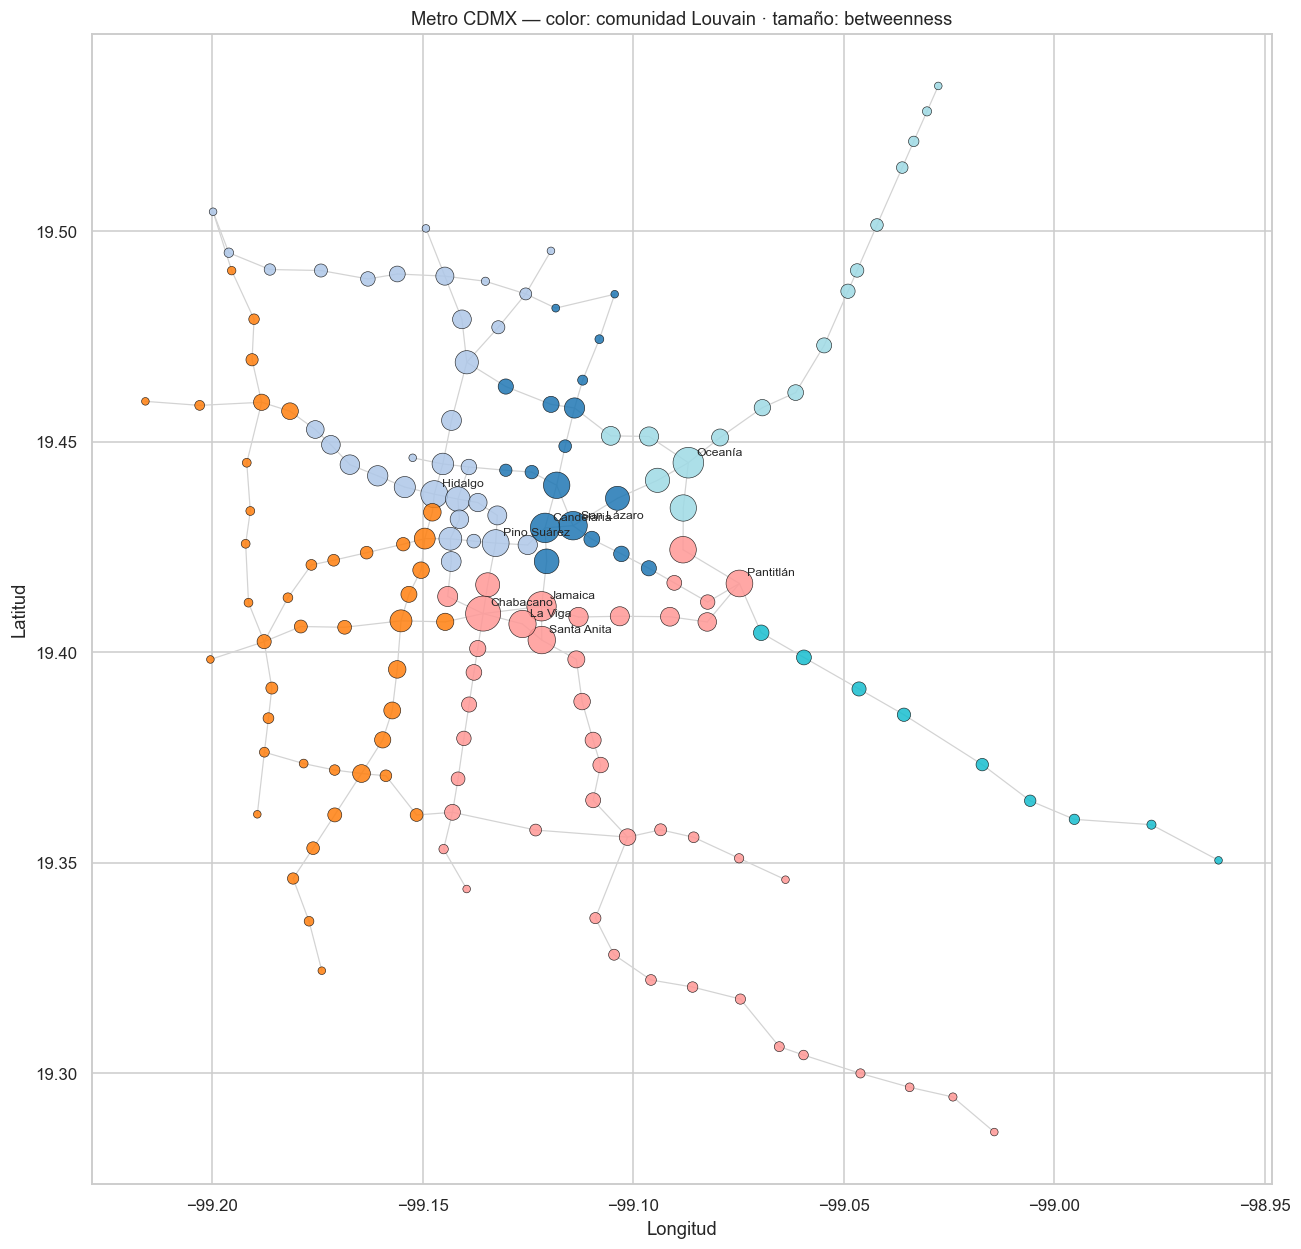

In [96]:
edges = gds.run_cypher("""
    MATCH (o:estacion)-[r:CONECTA_CON]->(d:estacion)
    RETURN o.lon AS o_lon, o.lat AS o_lat,
           d.lon AS d_lon, d.lat AS d_lat
""")

fig, ax = plt.subplots(figsize=(12, 12))

# aristas como líneas grises
for _, e in edges.iterrows():
    ax.plot([e.o_lon, e.d_lon], [e.o_lat, e.d_lat],
            color="lightgray", lw=0.8, zorder=1)

# estaciones: color = comunidad, tamaño = betweenness
sizes = 25 + (df["betweenness"] / df["betweenness"].max()) * 500
sc = ax.scatter(df["lon"], df["lat"], c=df["comunidad"], s=sizes,
                cmap="tab20", alpha=0.85, edgecolor="black", lw=0.4, zorder=2)

# etiquetar top 10 por betweenness
top = df.nlargest(10, "betweenness")
for _, r in top.iterrows():
    ax.annotate(r["estacion"], (r["lon"], r["lat"]),
                fontsize=8, xytext=(5, 5), textcoords="offset points")

ax.set_title("Metro CDMX — color: comunidad Louvain · tamaño: betweenness")
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
ax.set_aspect("equal")
plt.tight_layout()

**Heatmap de correlaciones entre métricas**

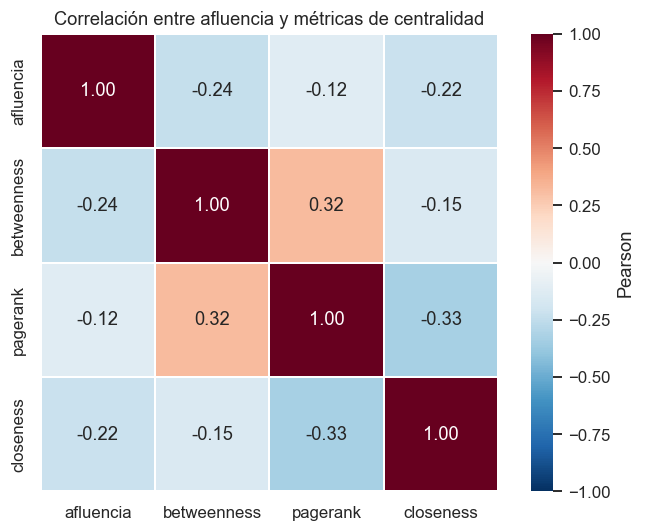

In [97]:
fig, ax = plt.subplots(figsize=(6.5, 5))
corr = df[["afluencia", "betweenness", "pagerank", "closeness"]].corr()
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, fmt=".2f", square=True,
            linewidths=1, cbar_kws={"label": "Pearson"}, ax=ax)
ax.set_title("Correlación entre afluencia y métricas de centralidad")
plt.tight_layout()

**Histograma de afluencia, lineal y logarítmica**

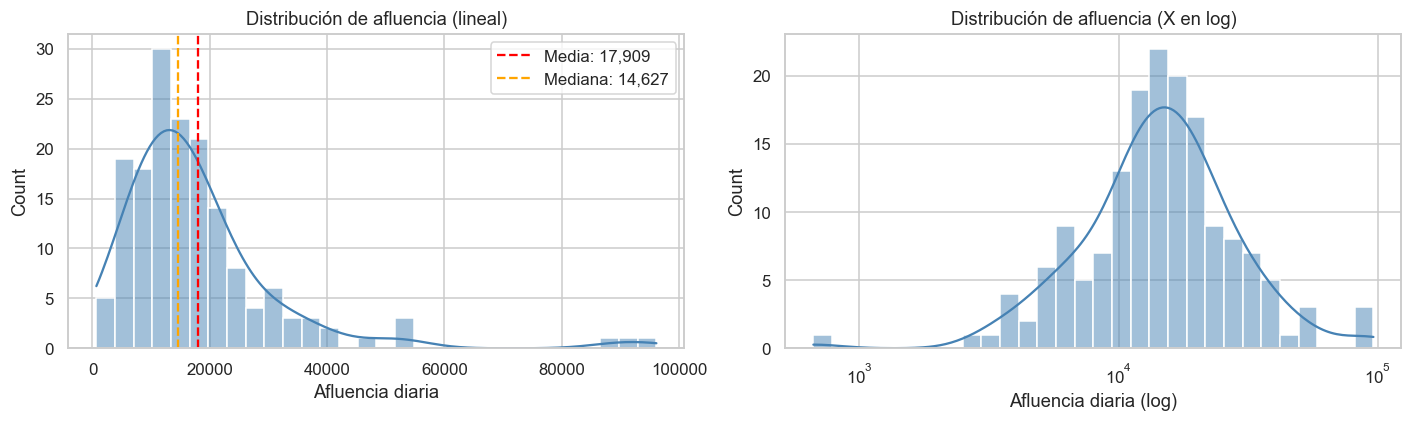

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df["afluencia"], bins=30, kde=True, color="steelblue", ax=axes[0])
axes[0].axvline(df["afluencia"].mean(),   color="red",    ls="--",
                label=f"Media: {df['afluencia'].mean():,.0f}")
axes[0].axvline(df["afluencia"].median(), color="orange", ls="--",
                label=f"Mediana: {df['afluencia'].median():,.0f}")
axes[0].set_title("Distribución de afluencia (lineal)")
axes[0].set_xlabel("Afluencia diaria"); axes[0].legend()

sns.histplot(df["afluencia"], bins=30, kde=True, color="steelblue",
             log_scale=(True, False), ax=axes[1])
axes[1].set_title("Distribución de afluencia (X en log)")
axes[1].set_xlabel("Afluencia diaria (log)")
plt.tight_layout()

### **Cerrar la conexión**

In [ ]:
gds.close()
driver.close()
print("Conexiones cerradas")